🍫 Chocolate Sales: Complete EDA + ML Pipeline


1. Setup & Data Loading

In [39]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [40]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import seaborn as sns
from matplotlib.gridspec import GridSpec

In [41]:
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier

In [42]:
import xgboost as xgb

print('✅ All libraries loaded successfully!')
print(f'   pandas  {pd.__version__}  |  numpy {np.__version__}  |  sklearn ready  |  xgboost ready')

✅ All libraries loaded successfully!
   pandas  2.2.2  |  numpy 2.0.2  |  sklearn ready  |  xgboost ready


In [43]:
sns.set_theme(style="whitegrid")
plt.rcParams['axes.facecolor']   = '#F5DEB3'   # Light brown background
plt.rcParams['figure.facecolor'] = '#FFF8F0'   # Light beige overall
plt.rcParams['axes.edgecolor']   = '#C4A484'   # Medium brown border
plt.rcParams['axes.labelcolor']  = '#4B2E05'   # Dark brown labels
plt.rcParams['xtick.color']      = '#4B2E05'
plt.rcParams['ytick.color']      = '#4B2E05'
plt.rcParams['text.color']       = 'black'
plt.rcParams['font.family']      = 'DejaVu Sans'
plt.rcParams['axes.titlesize']   = 14
plt.rcParams['axes.titleweight'] = 'bold'

# Colour palettes
CHOCO_PALETTE  = ['#3B1005','#6B2D0F','#A0522D','#C4A484','#D2B48C','#DEB887','#F5DEB3','#FFF8DC']
BRAND_PALETTE  = ['#3B1005','#6B2D0F','#A0522D','#C4A484','#8B6914','#D2691E']
COUNTRY_PAL    = sns.color_palette('YlOrBr', 6)

print('🎨 Theme set — chocolate mode activated!')

🎨 Theme set — chocolate mode activated!


In [44]:
calendar  = pd.read_csv('calendar.csv',  parse_dates=['date'])
customers = pd.read_csv('customers.csv', parse_dates=['join_date'])
products  = pd.read_csv('products.csv')
sales     = pd.read_csv('sales.csv',     parse_dates=['order_date'])
stores    = pd.read_csv('stores.csv')

In [45]:
print('📦 Dataset loaded:')
print(f'   Sales     : {sales.shape[0]:,} rows × {sales.shape[1]} cols')
print(f'   Customers : {customers.shape[0]:,} rows')
print(f'   Products  : {products.shape[0]:,} rows')
print(f'   Stores    : {stores.shape[0]:,} rows')
print(f'   Calendar  : {calendar.shape[0]:,} rows')
print(f'\n📅 Date range: {sales.order_date.min().date()} → {sales.order_date.max().date()}')

📦 Dataset loaded:
   Sales     : 1,000,000 rows × 11 cols
   Customers : 50,000 rows
   Products  : 200 rows
   Stores    : 100 rows
   Calendar  : 731 rows

📅 Date range: 2023-01-01 → 2024-12-31


2. Dataset Overview

In [46]:
for name, df in [('SALES', sales), ('CUSTOMERS', customers),
                 ('PRODUCTS', products), ('STORES', stores), ('CALENDAR', calendar)]:
    print(f'\n{'='*55}')
    print(f'  {name}')
    print(f'{'='*55}')
    print(df.dtypes.to_frame('dtype').assign(nulls=df.isnull().sum(),
                                              sample=df.iloc[0].values).to_string())


  SALES
                      dtype  nulls               sample
order_id             object      0          0RD00000001
order_date   datetime64[ns]      0  2023-01-07 00:00:00
product_id           object      0                P0080
store_id             object      0                 S093
customer_id          object      0              C040749
quantity              int64      0                    5
unit_price          float64      0                14.43
discount            float64      0                 0.15
revenue             float64      0                61.33
cost                float64      0                42.77
profit              float64      0                18.56

  CUSTOMERS
                         dtype  nulls               sample
customer_id             object      0              C000001
age                      int64      0                   40
gender                  object      0                 Male
loyalty_member           int64      0                    1
join_date  

In [47]:
sales[['quantity','unit_price','discount','revenue','cost','profit']].describe().round(2)

,quantity,unit_price,discount,revenue,cost,profit
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00
mean,3.00,9.00,0.06,25.49,15.29,10.19
std,1.41,3.46,0.08,16.37,9.97,6.78
min,1.00,3.00,0.00,2.40,1.20,0.73
25%,2.00,6.00,0.00,12.16,7.24,4.78
50%,3.00,9.01,0.00,21.92,13.03,8.60
75%,4.00,12.00,0.15,35.88,21.41,14.17
max,5.00,15.00,0.20,75.00,52.43,37.43


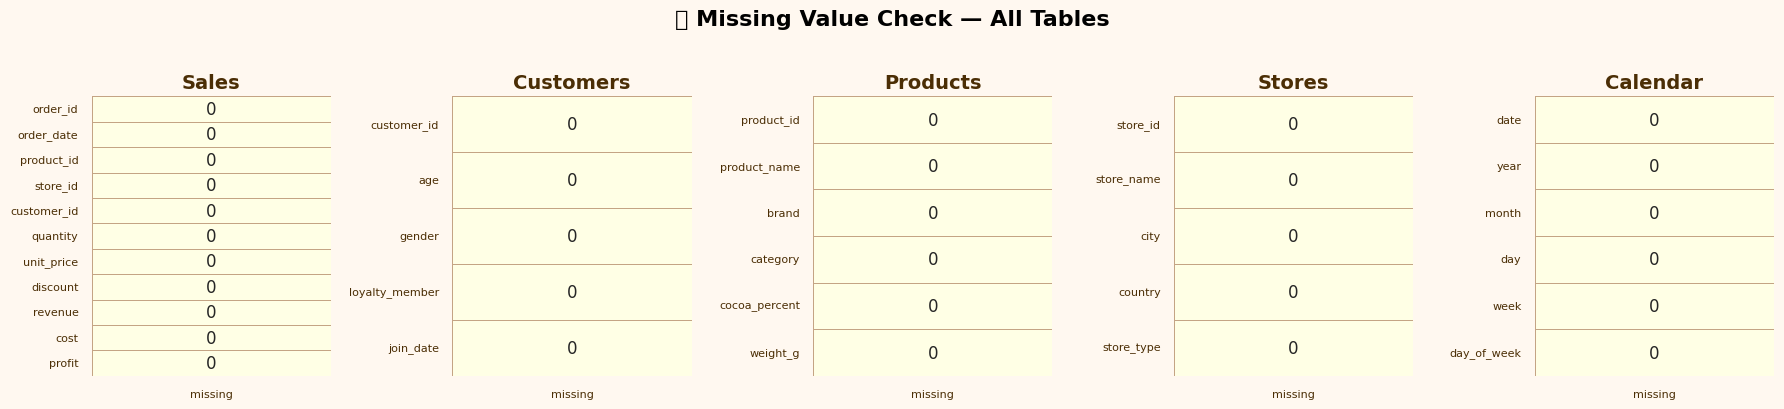

✅ No missing values found — clean dataset!


In [48]:
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('🔍 Missing Value Check — All Tables', fontsize=16, fontweight='bold', y=1.02)

for ax, (name, df) in zip(axes, [('Sales', sales), ('Customers', customers),
                                   ('Products', products), ('Stores', stores),
                                   ('Calendar', calendar)]):
    miss = df.isnull().sum().to_frame('missing')
    sns.heatmap(miss, ax=ax, annot=True, fmt='d', cmap='YlOrBr',
                cbar=False, linewidths=0.5, linecolor='#C4A484')
    ax.set_title(name, fontweight='bold', color='#4B2E05')
    ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()
print('✅ No missing values found — clean dataset!')

3. Data Cleaning & Feature Engineering

In [49]:
# ── Master merged dataframe ────────────────────────────────────────────────────
df = (sales
      .merge(products,  on='product_id',  how='left')
      .merge(stores,    on='store_id',    how='left')
      .merge(customers, on='customer_id', how='left'))

# ── Time features ─────────────────────────────────────────────────────────────
df['year']        = df['order_date'].dt.year
df['month']       = df['order_date'].dt.month
df['month_name']  = df['order_date'].dt.strftime('%b')
df['quarter']     = df['order_date'].dt.quarter
df['day_of_week'] = df['order_date'].dt.dayofweek
df['week']        = df['order_date'].dt.isocalendar().week.astype(int)
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)

# ── Business KPIs ─────────────────────────────────────────────────────────────
df['profit_margin']      = (df['profit'] / df['revenue'] * 100).round(2)
df['revenue_per_unit']   = (df['revenue'] / df['quantity']).round(2)
df['has_discount']       = (df['discount'] > 0).astype(int)
df['discount_category']  = pd.cut(df['discount'],
                                   bins=[-0.01, 0, 0.1, 0.2, 1.0],
                                   labels=['No Discount','0–10%','10–20%','20%+'])
# ── Customer age bands ────────────────────────────────────────────────────────
df['age_band'] = pd.cut(df['age'], bins=[0,25,35,45,55,100],
                         labels=['<25','25–34','35–44','45–54','55+'])

print(f'✅ Master dataframe ready: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'   New engineered features: year, month, quarter, week, is_weekend,'
      f' profit_margin, revenue_per_unit, has_discount, discount_category, age_band')

✅ Master dataframe ready: 1,000,000 rows × 36 columns
   New engineered features: year, month, quarter, week, is_weekend, profit_margin, revenue_per_unit, has_discount, discount_category, age_band



4. Exploratory Data Analysis — Sales & Revenue

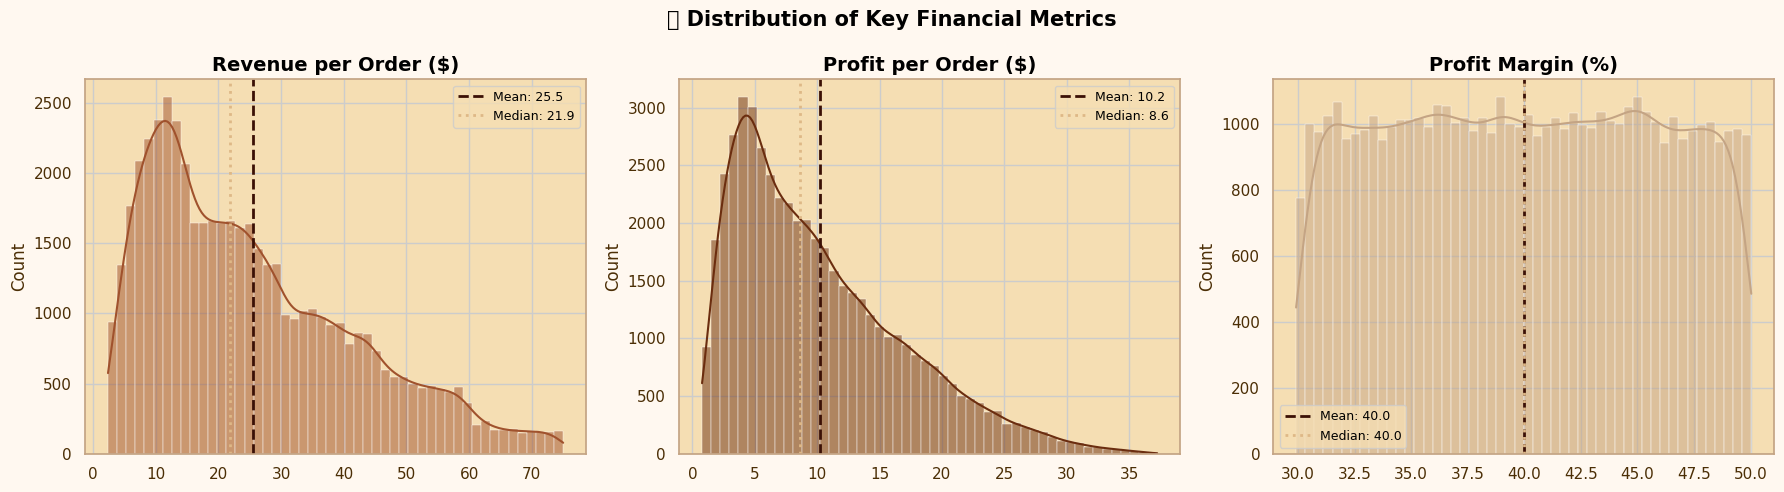

In [50]:
# ── Revenue & Profit Distributions ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('📊 Distribution of Key Financial Metrics', fontsize=15, fontweight='bold')

for ax, col, color, title in zip(
        axes,
        ['revenue', 'profit', 'profit_margin'],
        ['#A0522D', '#6B2D0F', '#C4A484'],
        ['Revenue per Order ($)', 'Profit per Order ($)', 'Profit Margin (%)']):
    sample = df[col].sample(50_000, random_state=42)
    sns.histplot(sample, ax=ax, color=color, bins=50, kde=True,
                 edgecolor='white', linewidth=0.3)
    ax.axvline(sample.mean(), color='#3B1005', lw=2, ls='--', label=f'Mean: {sample.mean():.1f}')
    ax.axvline(sample.median(), color='#DEB887', lw=2, ls=':', label=f'Median: {sample.median():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

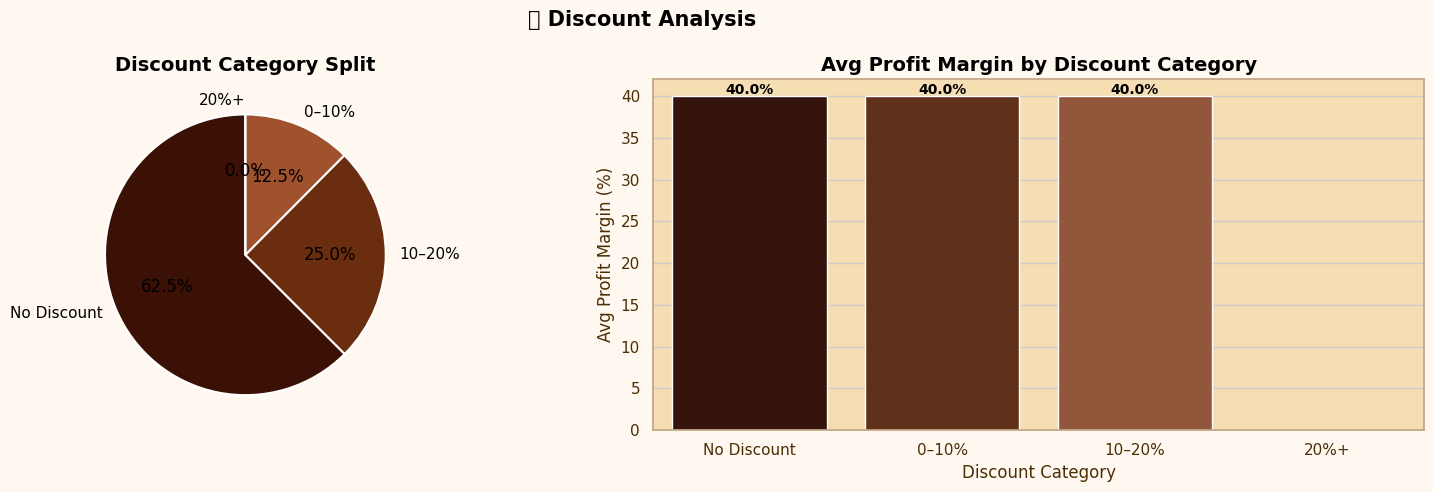

In [51]:
# ── Discount Impact ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('🏷️ Discount Analysis', fontsize=15, fontweight='bold')

# Discount category distribution
disc_counts = df['discount_category'].value_counts()
axes[0].pie(disc_counts, labels=disc_counts.index, autopct='%1.1f%%',
            colors=['#3B1005','#6B2D0F','#A0522D','#D2B48C'],
            startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
axes[0].set_title('Discount Category Split', fontweight='bold')

# Avg profit margin by discount category
disc_margin = df.groupby('discount_category', observed=True)['profit_margin'].mean().reset_index()
sns.barplot(data=disc_margin, x='discount_category', y='profit_margin',
            palette=['#3B1005','#6B2D0F','#A0522D','#D2B48C'], ax=axes[1])
axes[1].set_title('Avg Profit Margin by Discount Category', fontweight='bold')
axes[1].set_xlabel('Discount Category')
axes[1].set_ylabel('Avg Profit Margin (%)')
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()


5. Product Analysis

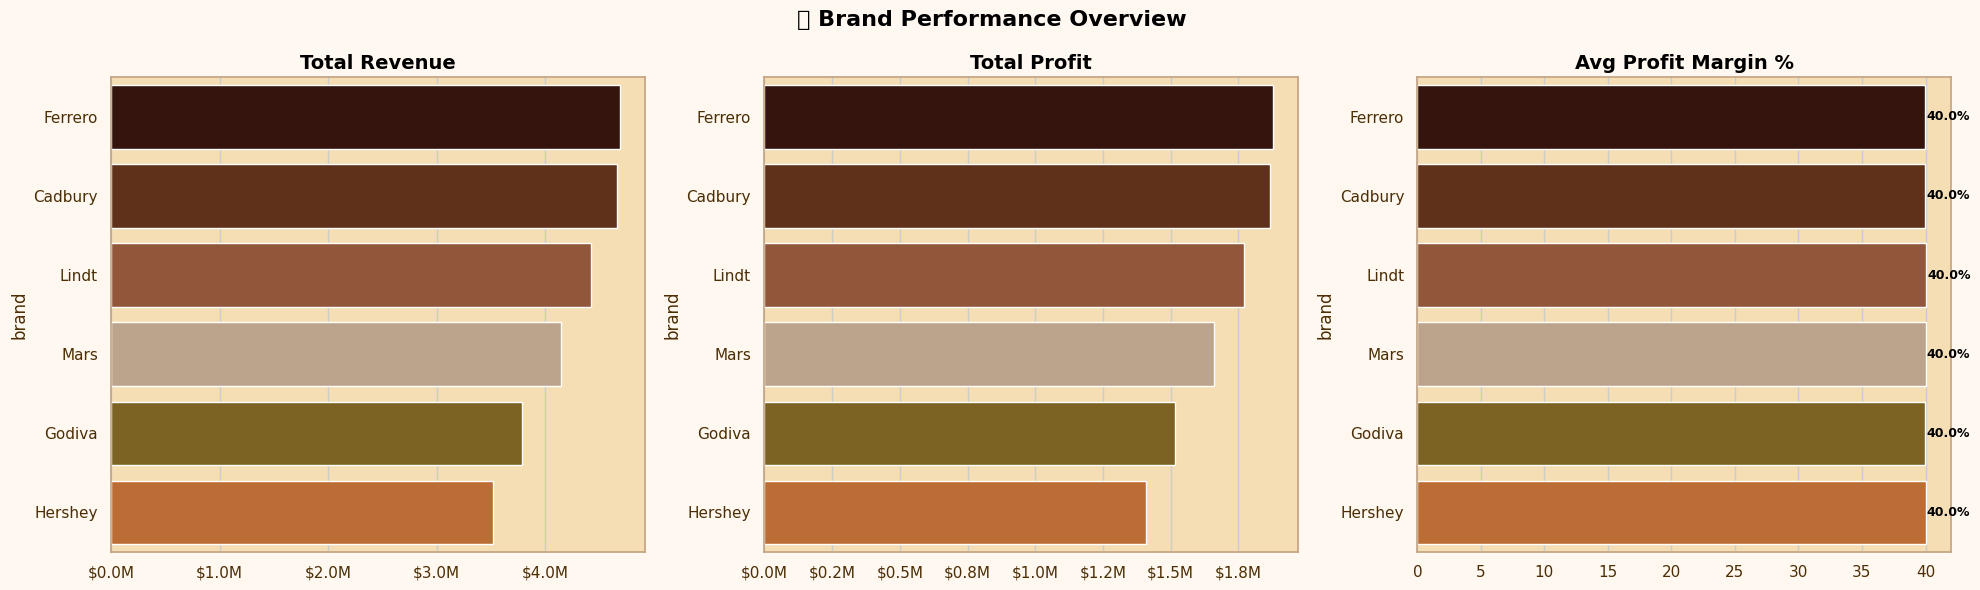

In [52]:
# ── Revenue & Profit by Brand ─────────────────────────────────────────────────
brand_agg = df.groupby('brand').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    orders=('order_id','count'),
    margin=('profit_margin','mean')
).sort_values('revenue', ascending=False).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('🏭 Brand Performance Overview', fontsize=16, fontweight='bold')

# Revenue
sns.barplot(data=brand_agg, y='brand', x='revenue', palette=BRAND_PALETTE,
            orient='h', ax=axes[0])
axes[0].set_title('Total Revenue', fontweight='bold')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[0].set_xlabel('')

# Profit
sns.barplot(data=brand_agg, y='brand', x='profit', palette=BRAND_PALETTE,
            orient='h', ax=axes[1])
axes[1].set_title('Total Profit', fontweight='bold')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
axes[1].set_xlabel('')

# Margin
bars = sns.barplot(data=brand_agg, y='brand', x='margin', palette=BRAND_PALETTE,
                   orient='h', ax=axes[2])
axes[2].set_title('Avg Profit Margin %', fontweight='bold')
axes[2].set_xlabel('')
for p in axes[2].patches:
    axes[2].text(p.get_width()+0.1, p.get_y()+p.get_height()/2,
                 f'{p.get_width():.1f}%', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

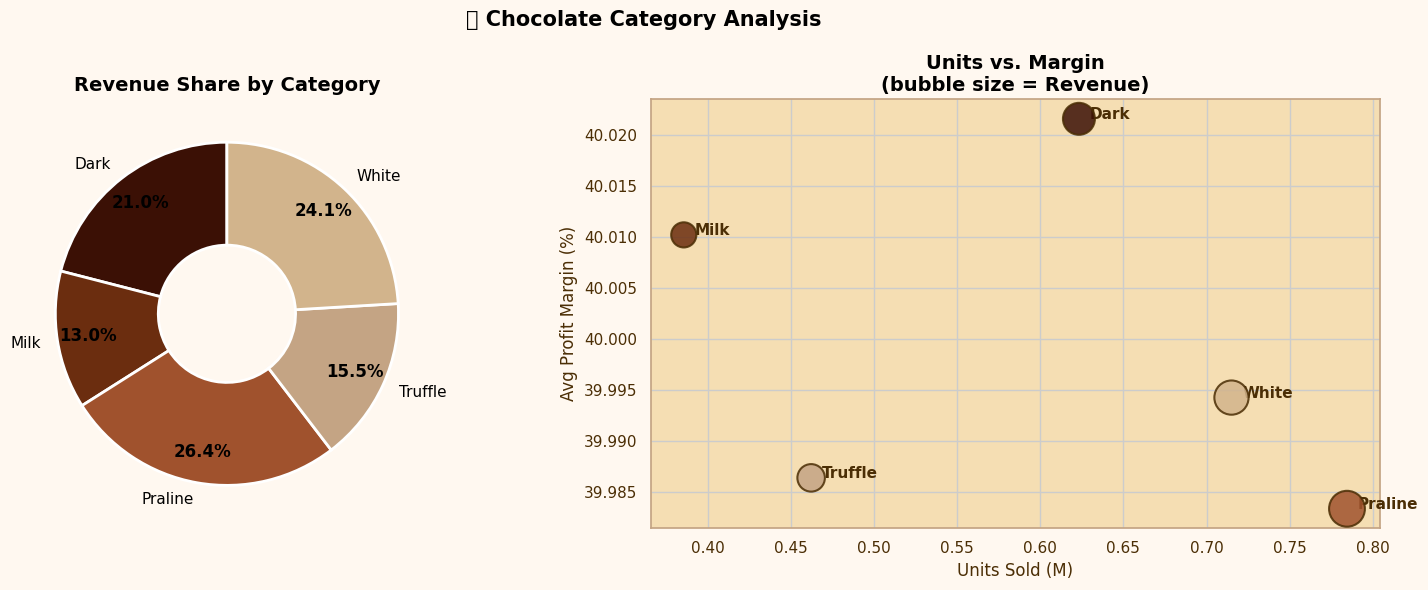

In [53]:
# ── Category Performance ──────────────────────────────────────────────────────
cat_agg = df.groupby('category').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    units=('quantity','sum'),
    margin=('profit_margin','mean')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('🍫 Chocolate Category Analysis', fontsize=15, fontweight='bold')

# Donut — revenue share
wedges, texts, autotexts = axes[0].pie(
    cat_agg['revenue'], labels=cat_agg['category'],
    autopct='%1.1f%%', colors=CHOCO_PALETTE[:5],
    startangle=90, pctdistance=0.82,
    wedgeprops={'edgecolor':'white','linewidth':2, 'width':0.6})
for at in autotexts: at.set_fontweight('bold')
axes[0].set_title('Revenue Share by Category', fontweight='bold')

# Bubble: units vs margin, size=revenue
scatter = axes[1].scatter(cat_agg['units']/1e6, cat_agg['margin'],
                           s=cat_agg['revenue']/10000,
                           c=CHOCO_PALETTE[:5], edgecolors='#4B2E05',
                           linewidth=1.5, alpha=0.85, zorder=5)
for _, row in cat_agg.iterrows():
    axes[1].annotate(row['category'],
                     (row['units']/1e6, row['margin']),
                     textcoords='offset points', xytext=(8,0),
                     fontsize=11, fontweight='bold', color='#4B2E05')
axes[1].set_xlabel('Units Sold (M)', color='#4B2E05')
axes[1].set_ylabel('Avg Profit Margin (%)', color='#4B2E05')
axes[1].set_title('Units vs. Margin\n(bubble size = Revenue)', fontweight='bold')

plt.tight_layout()
plt.show()

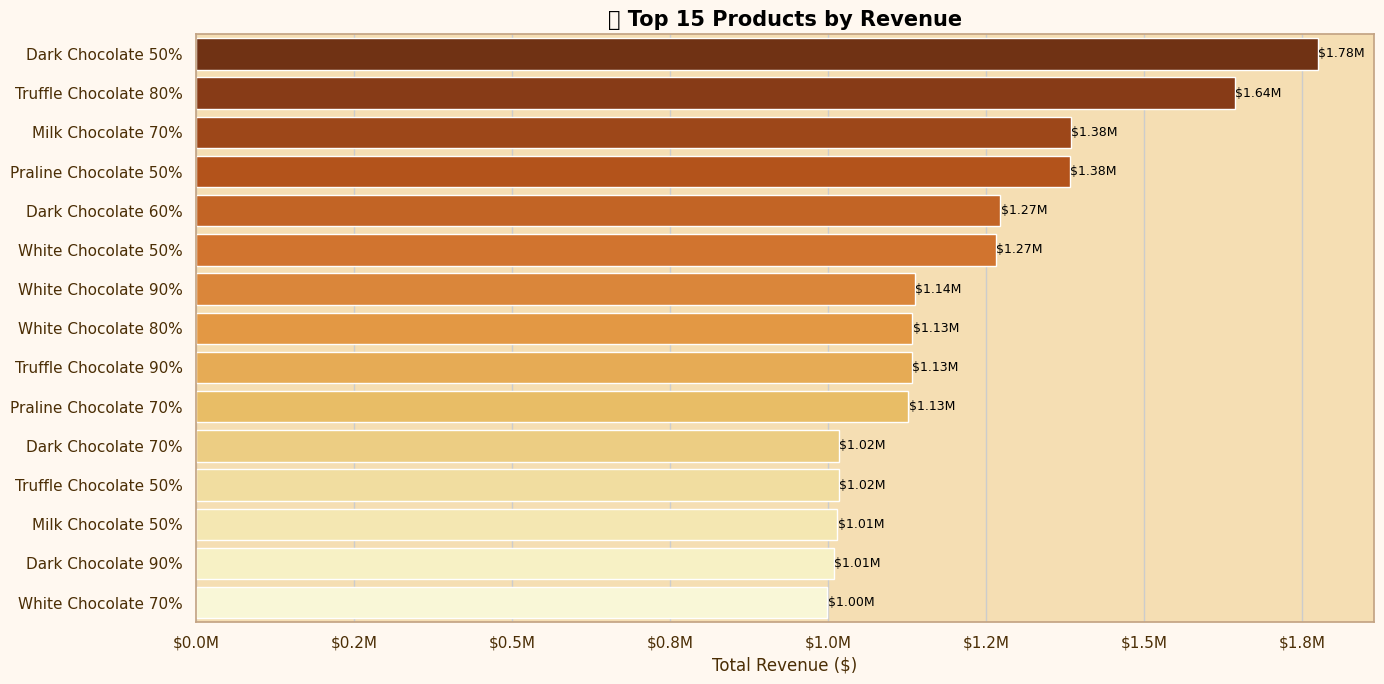

In [54]:
# ── Top 15 Products ────────────────────────────────────────────────────────────
top_products = (df.groupby('product_name')['revenue']
                  .sum().nlargest(15).reset_index())

fig, ax = plt.subplots(figsize=(14, 7))
bars = sns.barplot(data=top_products, y='product_name', x='revenue',
                   palette=sns.color_palette('YlOrBr_r', 15), ax=ax)
ax.set_title('🏆 Top 15 Products by Revenue', fontsize=15, fontweight='bold')
ax.set_xlabel('Total Revenue ($)', color='#4B2E05')
ax.set_ylabel('')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.1f}M'))
for p in ax.patches:
    ax.text(p.get_width()+500, p.get_y()+p.get_height()/2,
            f'${p.get_width()/1e6:.2f}M', va='center', fontsize=9)
plt.tight_layout()
plt.show()

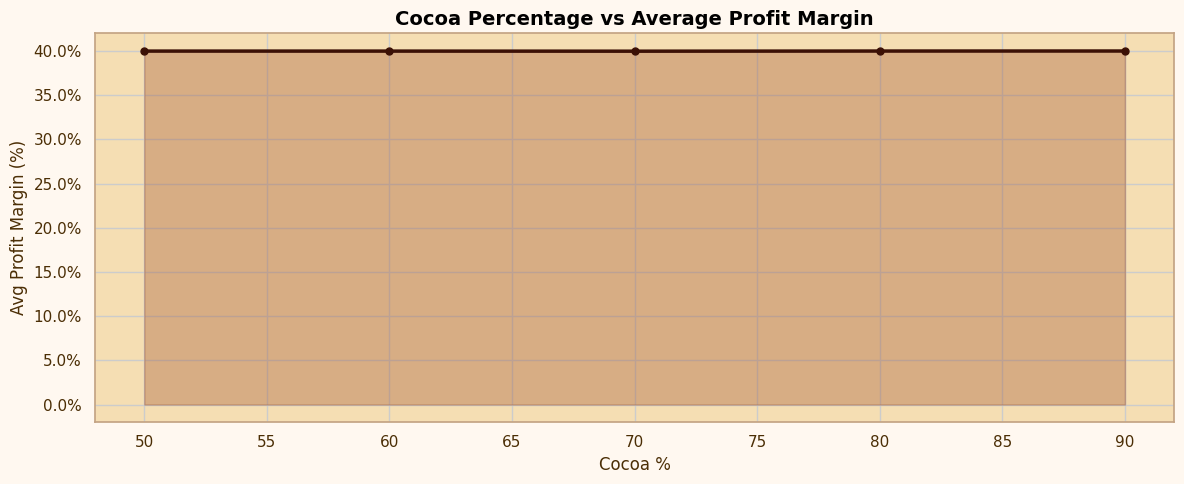

In [55]:
# ── Cocoa % vs Profit Margin ──────────────────────────────────────────────────
cocoa_margin = df.groupby('cocoa_percent')['profit_margin'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.fill_between(cocoa_margin['cocoa_percent'], cocoa_margin['profit_margin'],
                alpha=0.35, color='#A0522D')
ax.plot(cocoa_margin['cocoa_percent'], cocoa_margin['profit_margin'],
        color='#3B1005', lw=2.5, marker='o', markersize=5)
ax.set_title('Cocoa Percentage vs Average Profit Margin', fontsize=14, fontweight='bold')
ax.set_xlabel('Cocoa %', color='#4B2E05')
ax.set_ylabel('Avg Profit Margin (%)', color='#4B2E05')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

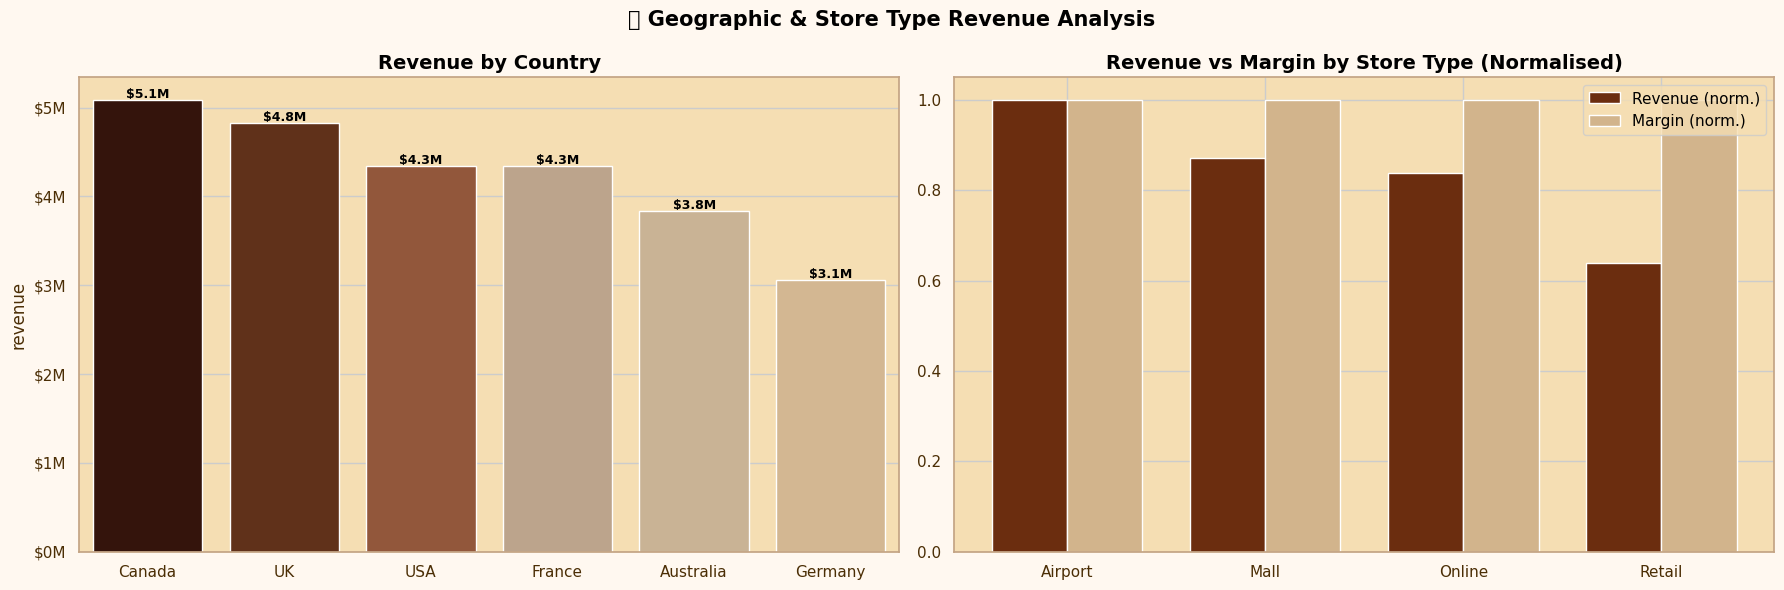

In [56]:
# ── Revenue by Country & Store Type ───────────────────────────────────────────
country_agg = df.groupby('country').agg(
    revenue=('revenue','sum'),
    profit=('profit','sum'),
    orders=('order_id','count')
).reset_index().sort_values('revenue', ascending=False)

store_type_agg = df.groupby('store_type').agg(
    revenue=('revenue','sum'),
    margin=('profit_margin','mean')
).reset_index().sort_values('revenue', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('🌍 Geographic & Store Type Revenue Analysis', fontsize=15, fontweight='bold')

# Country
sns.barplot(data=country_agg, x='country', y='revenue',
            palette=CHOCO_PALETTE[:6], ax=axes[0])
axes[0].set_title('Revenue by Country', fontweight='bold')
axes[0].set_xlabel('')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
for p in axes[0].patches:
    axes[0].text(p.get_x()+p.get_width()/2, p.get_height()+2e4,
                 f'${p.get_height()/1e6:.1f}M', ha='center', fontsize=9, fontweight='bold')

# Store type — twin bar
x = range(len(store_type_agg))
w = 0.38
rev_norm = store_type_agg['revenue']/store_type_agg['revenue'].max()
mar_norm = store_type_agg['margin']/store_type_agg['margin'].max()
axes[1].bar([i-w/2 for i in x], rev_norm, width=w, color='#6B2D0F', label='Revenue (norm.)')
axes[1].bar([i+w/2 for i in x], mar_norm, width=w, color='#D2B48C', label='Margin (norm.)')
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(store_type_agg['store_type'])
axes[1].set_title('Revenue vs Margin by Store Type (Normalised)', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

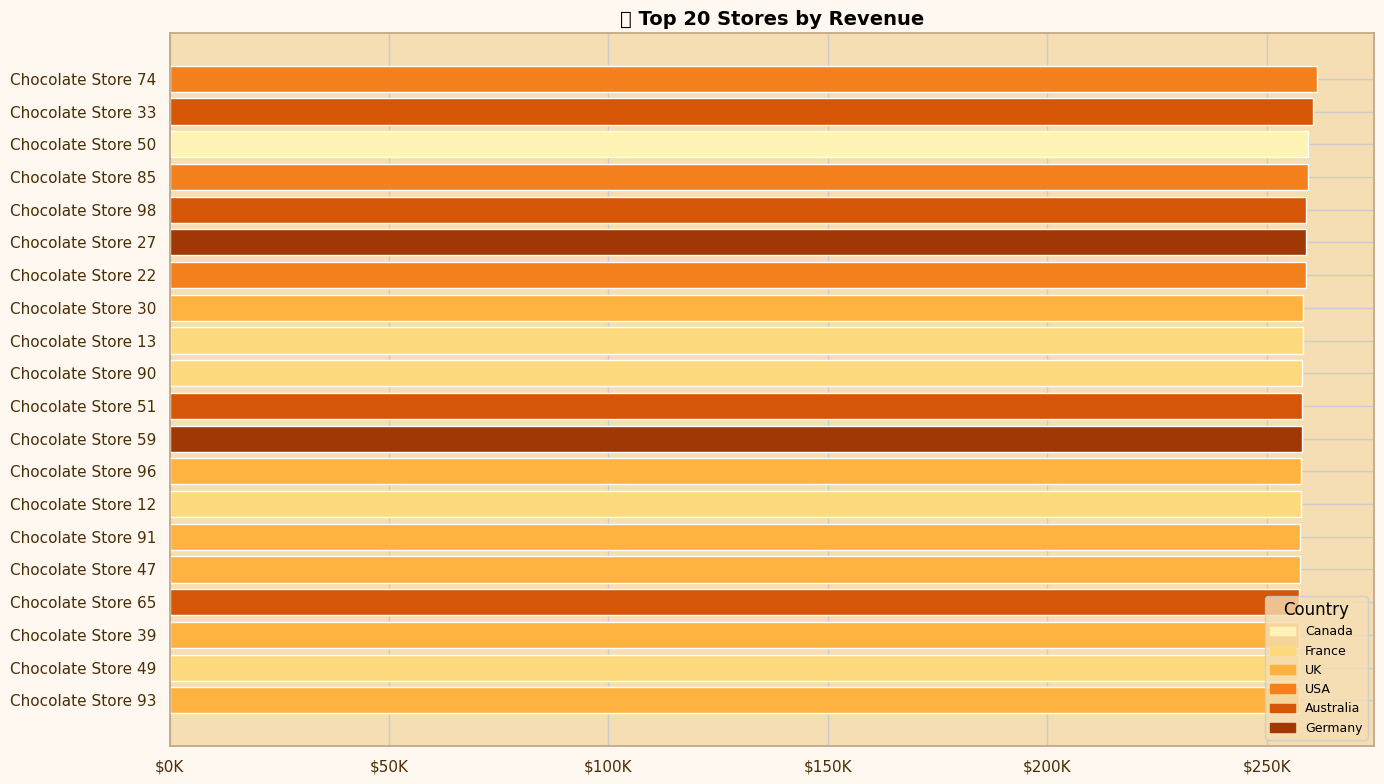

In [57]:
# ── Top 20 Stores ─────────────────────────────────────────────────────────────
top_stores = (df.groupby(['store_id','store_name','country'])
                .agg(revenue=('revenue','sum'), profit=('profit','sum'))
                .reset_index()
                .sort_values('revenue', ascending=False)
                .head(20))

fig, ax = plt.subplots(figsize=(14, 8))
colors_c = [COUNTRY_PAL[['Canada','France','UK','USA','Australia','Germany'].index(c)]
            for c in top_stores['country']]
bars = ax.barh(top_stores['store_name'], top_stores['revenue'], color=colors_c)
ax.set_title('🏪 Top 20 Stores by Revenue', fontsize=14, fontweight='bold')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e3:.0f}K'))
ax.invert_yaxis()
handles = [mpatches.Patch(color=COUNTRY_PAL[i], label=c)
           for i,c in enumerate(['Canada','France','UK','USA','Australia','Germany'])]
ax.legend(handles=handles, title='Country', loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()


7. Customer Analysis

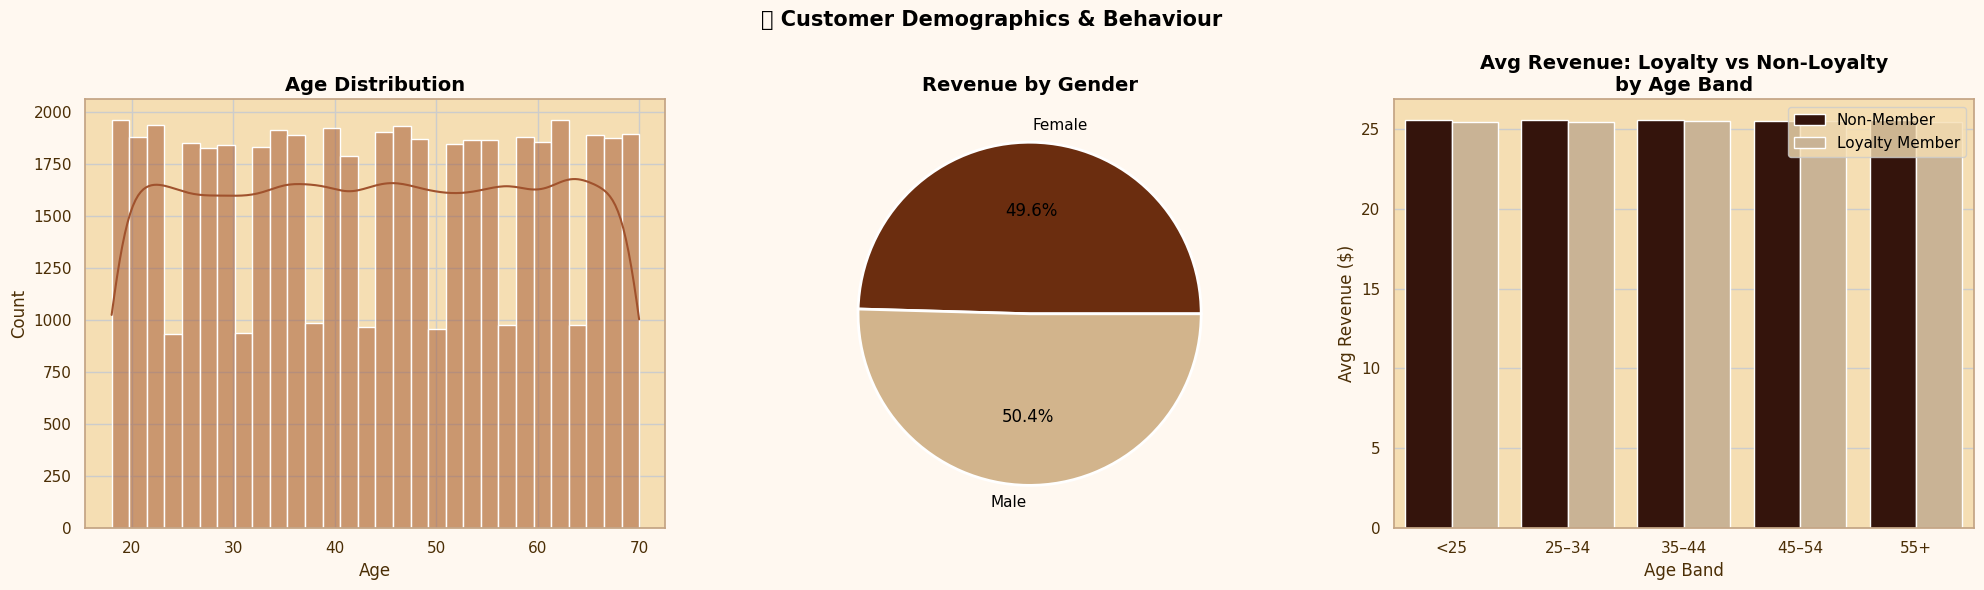

In [58]:
# ── Customer demographics ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('👥 Customer Demographics & Behaviour', fontsize=15, fontweight='bold')

# Age distribution
sns.histplot(data=df.drop_duplicates('customer_id'), x='age',
             bins=30, color='#A0522D', kde=True, ax=axes[0])
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].set_xlabel('Age')

# Gender split
gender_rev = df.groupby('gender')['revenue'].sum()
axes[1].pie(gender_rev, labels=gender_rev.index, autopct='%1.1f%%',
            colors=['#6B2D0F','#D2B48C'],
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[1].set_title('Revenue by Gender', fontweight='bold')

# Loyalty vs non-loyalty revenue
loyalty_rev = df.groupby(['loyalty_member','age_band'], observed=True)['revenue'].mean().reset_index()
loyalty_rev['loyalty_label'] = loyalty_rev['loyalty_member'].map({1:'Loyalty Member',0:'Non-Member'})
sns.barplot(data=loyalty_rev, x='age_band', y='revenue', hue='loyalty_label',
            palette=['#3B1005','#D2B48C'], ax=axes[2])
axes[2].set_title('Avg Revenue: Loyalty vs Non-Loyalty\nby Age Band', fontweight='bold')
axes[2].set_xlabel('Age Band')
axes[2].set_ylabel('Avg Revenue ($)')
axes[2].legend(title='')

plt.tight_layout()
plt.show()

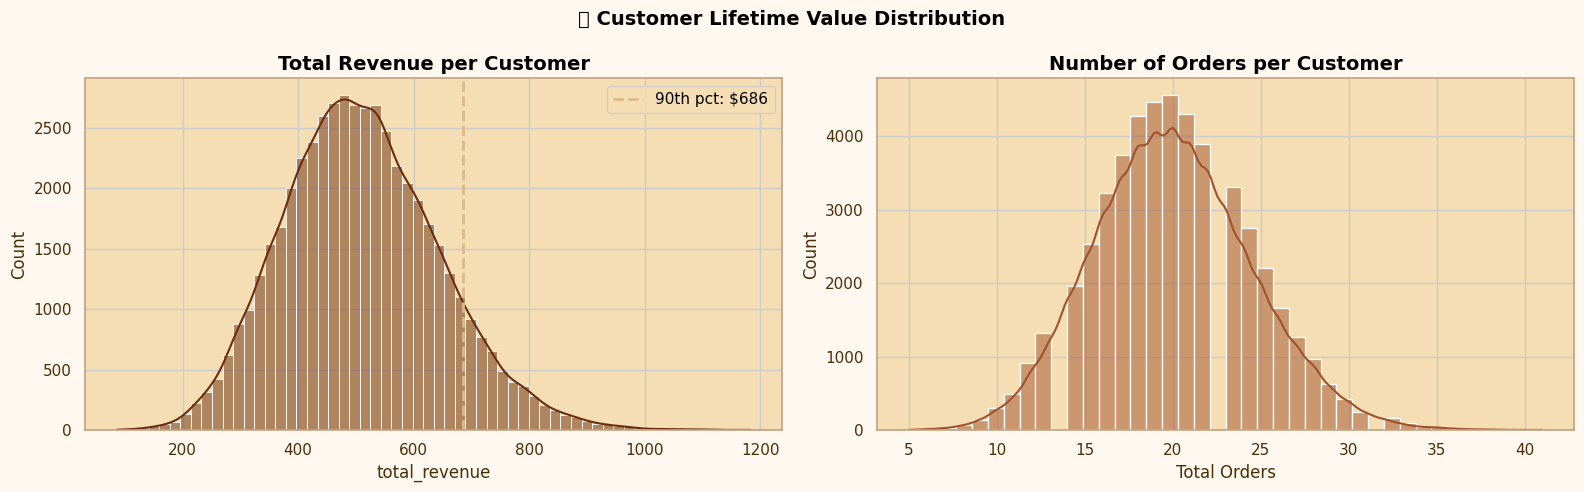

Avg orders per customer : 20.0
Avg lifetime revenue    : $509.72
Top 10% customers earn  : $685.56+


In [59]:
# ── Customer LTV proxy ────────────────────────────────────────────────────────
cust_ltv = (df.groupby('customer_id')
              .agg(total_revenue=('revenue','sum'),
                   total_orders=('order_id','count'),
                   total_profit=('profit','sum'),
                   avg_order_val=('revenue','mean'))
              .reset_index())

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('💎 Customer Lifetime Value Distribution', fontsize=14, fontweight='bold')

# LTV histogram
sns.histplot(cust_ltv['total_revenue'], bins=60, color='#6B2D0F', kde=True, ax=axes[0])
axes[0].axvline(cust_ltv['total_revenue'].quantile(0.9), color='#DEB887', ls='--', lw=2,
                label=f'90th pct: ${cust_ltv["total_revenue"].quantile(0.9):.0f}')
axes[0].set_title('Total Revenue per Customer', fontweight='bold')
axes[0].legend()

# Orders per customer
sns.histplot(cust_ltv['total_orders'], bins=40, color='#A0522D', kde=True, ax=axes[1])
axes[1].set_title('Number of Orders per Customer', fontweight='bold')
axes[1].set_xlabel('Total Orders')

plt.tight_layout()
plt.show()

print(f'Avg orders per customer : {cust_ltv["total_orders"].mean():.1f}')
print(f'Avg lifetime revenue    : ${cust_ltv["total_revenue"].mean():.2f}')
print(f'Top 10% customers earn  : ${cust_ltv["total_revenue"].quantile(0.9):.2f}+')


8. Time-Series & Seasonality

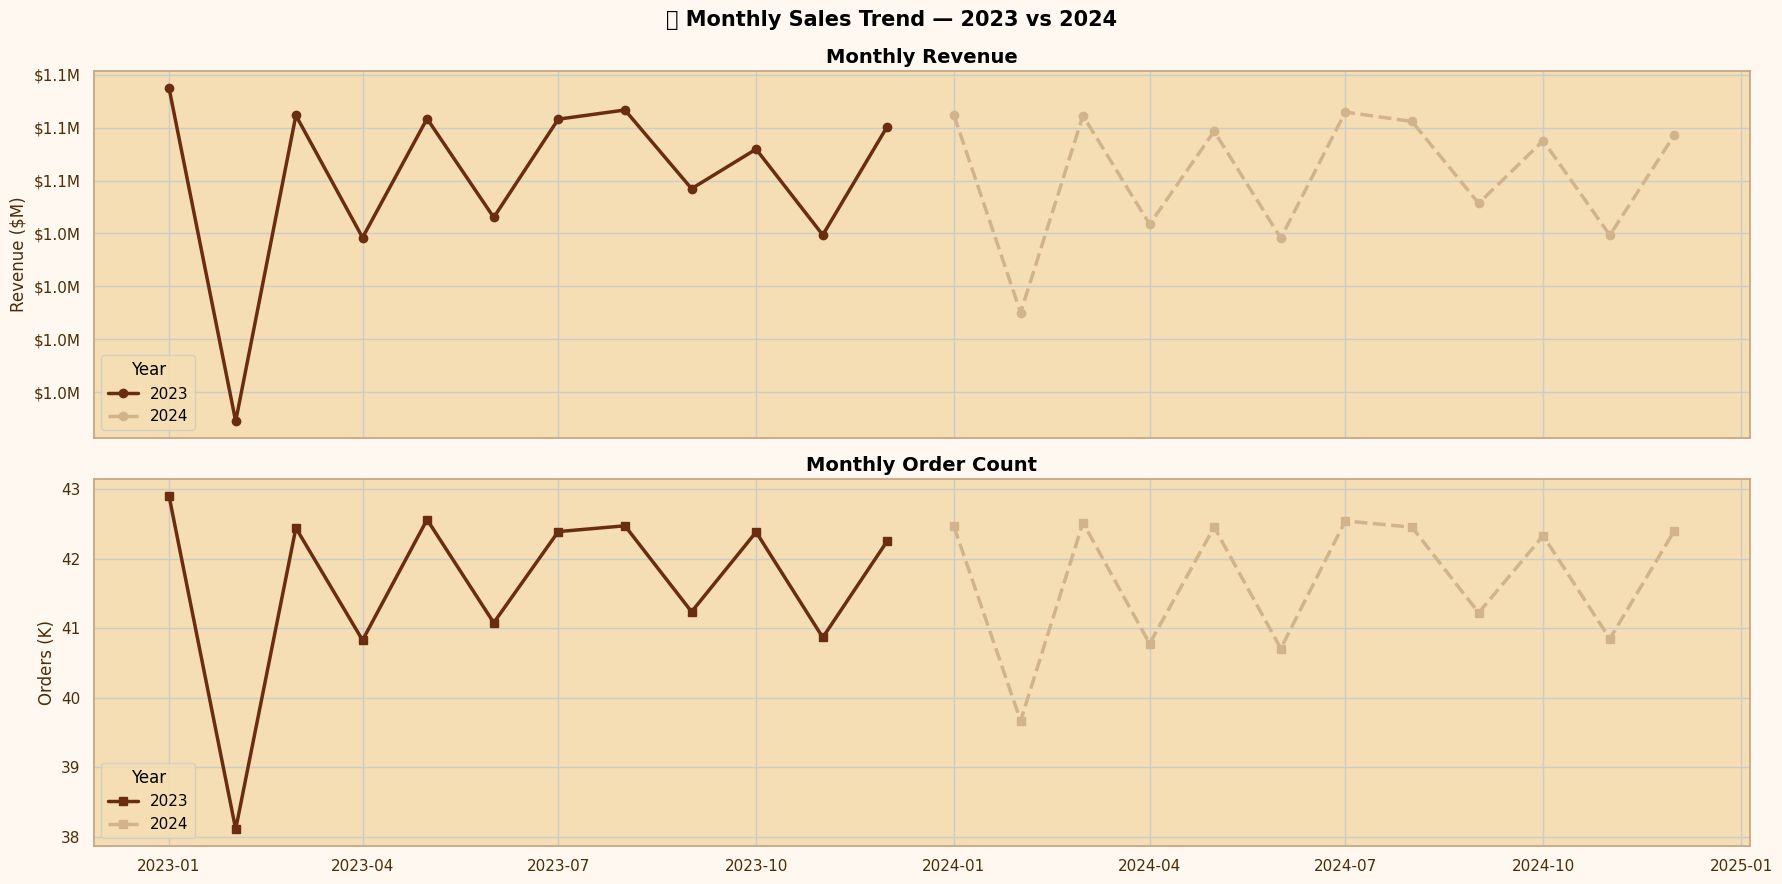

In [60]:
# ── Monthly Revenue Trend ─────────────────────────────────────────────────────
monthly = (df.groupby(['year','month'])
             .agg(revenue=('revenue','sum'), profit=('profit','sum'), orders=('order_id','count'))
             .reset_index())
monthly['period'] = pd.to_datetime(monthly[['year','month']].assign(day=1))

fig, axes = plt.subplots(2, 1, figsize=(18, 9), sharex=True)
fig.suptitle('📅 Monthly Sales Trend — 2023 vs 2024', fontsize=15, fontweight='bold')

for year, color, ls in [(2023,'#6B2D0F','-'), (2024,'#D2B48C','--')]:
    sub = monthly[monthly['year']==year]
    axes[0].plot(sub['period'], sub['revenue']/1e6, marker='o', lw=2.5,
                 color=color, ls=ls, label=str(year))
    axes[1].plot(sub['period'], sub['orders']/1000, marker='s', lw=2.5,
                 color=color, ls=ls, label=str(year))

axes[0].set_ylabel('Revenue ($M)', color='#4B2E05')
axes[0].set_title('Monthly Revenue', fontweight='bold')
axes[0].legend(title='Year')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x:.1f}M'))

axes[1].set_ylabel('Orders (K)', color='#4B2E05')
axes[1].set_title('Monthly Order Count', fontweight='bold')
axes[1].legend(title='Year')

plt.tight_layout()
plt.show()

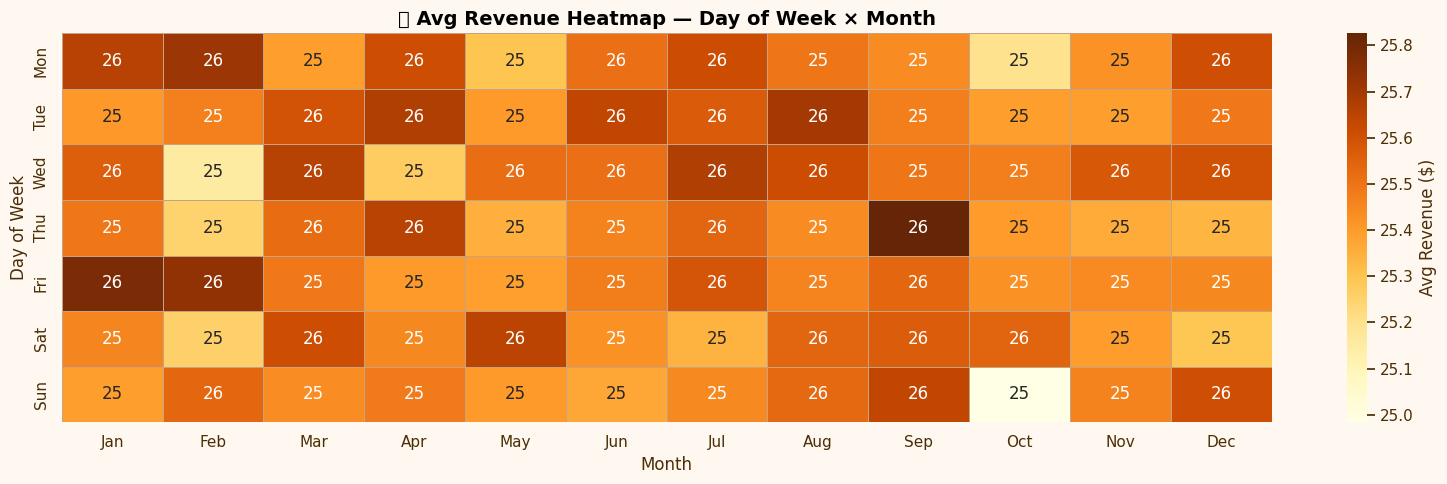

In [61]:
# ── Heatmap: Day-of-Week × Month ──────────────────────────────────────────────
pivot = (df.groupby(['day_of_week','month'])['revenue']
           .mean().unstack())
pivot.index = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
pivot.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                 'Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(pivot, cmap='YlOrBr', ax=ax, annot=True, fmt='.0f',
            linewidths=0.5, linecolor='#C4A484',
            cbar_kws={'label':'Avg Revenue ($)'})
ax.set_title('🗓️ Avg Revenue Heatmap — Day of Week × Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month', color='#4B2E05')
ax.set_ylabel('Day of Week', color='#4B2E05')
plt.tight_layout()
plt.show()

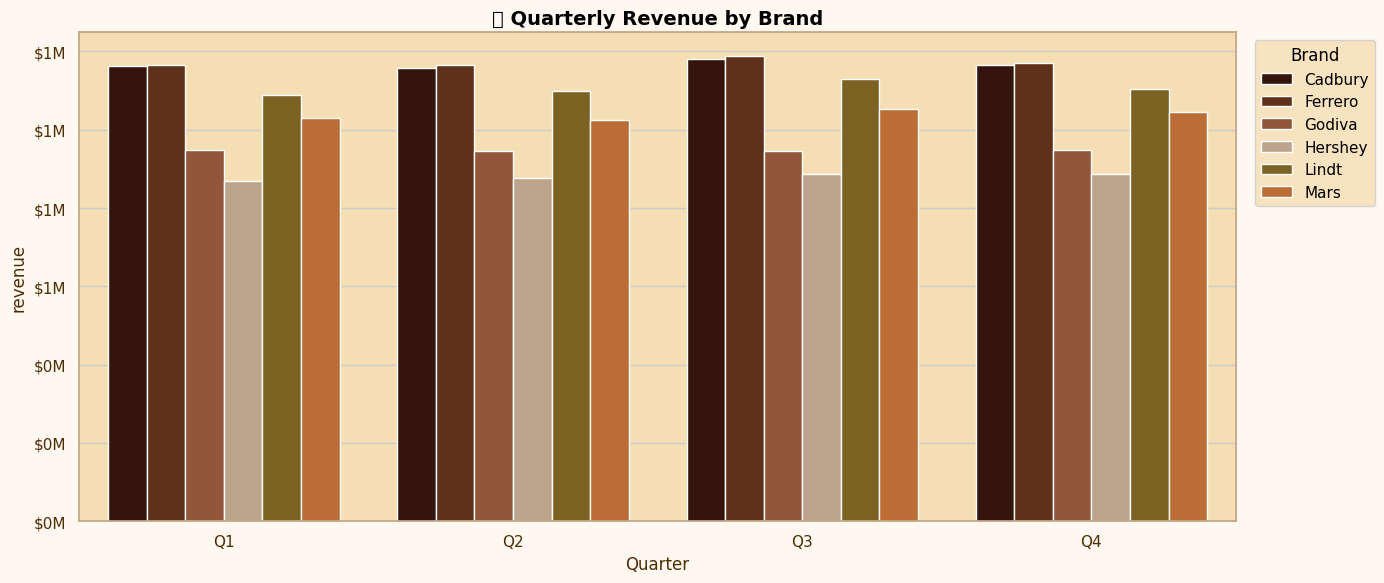

In [62]:
# ── Quarterly breakdown by brand ──────────────────────────────────────────────
qtr_brand = (df.groupby(['quarter','brand'])['revenue']
               .sum().reset_index())

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(data=qtr_brand, x='quarter', y='revenue', hue='brand',
            palette=BRAND_PALETTE, ax=ax)
ax.set_title('📊 Quarterly Revenue by Brand', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter', color='#4B2E05')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x,_: f'${x/1e6:.0f}M'))
ax.legend(title='Brand', bbox_to_anchor=(1.01,1), loc='upper left')
ax.set_xticklabels([f'Q{q}' for q in [1,2,3,4]])
plt.tight_layout()
plt.show()


9. Correlation & Statistical Analysis

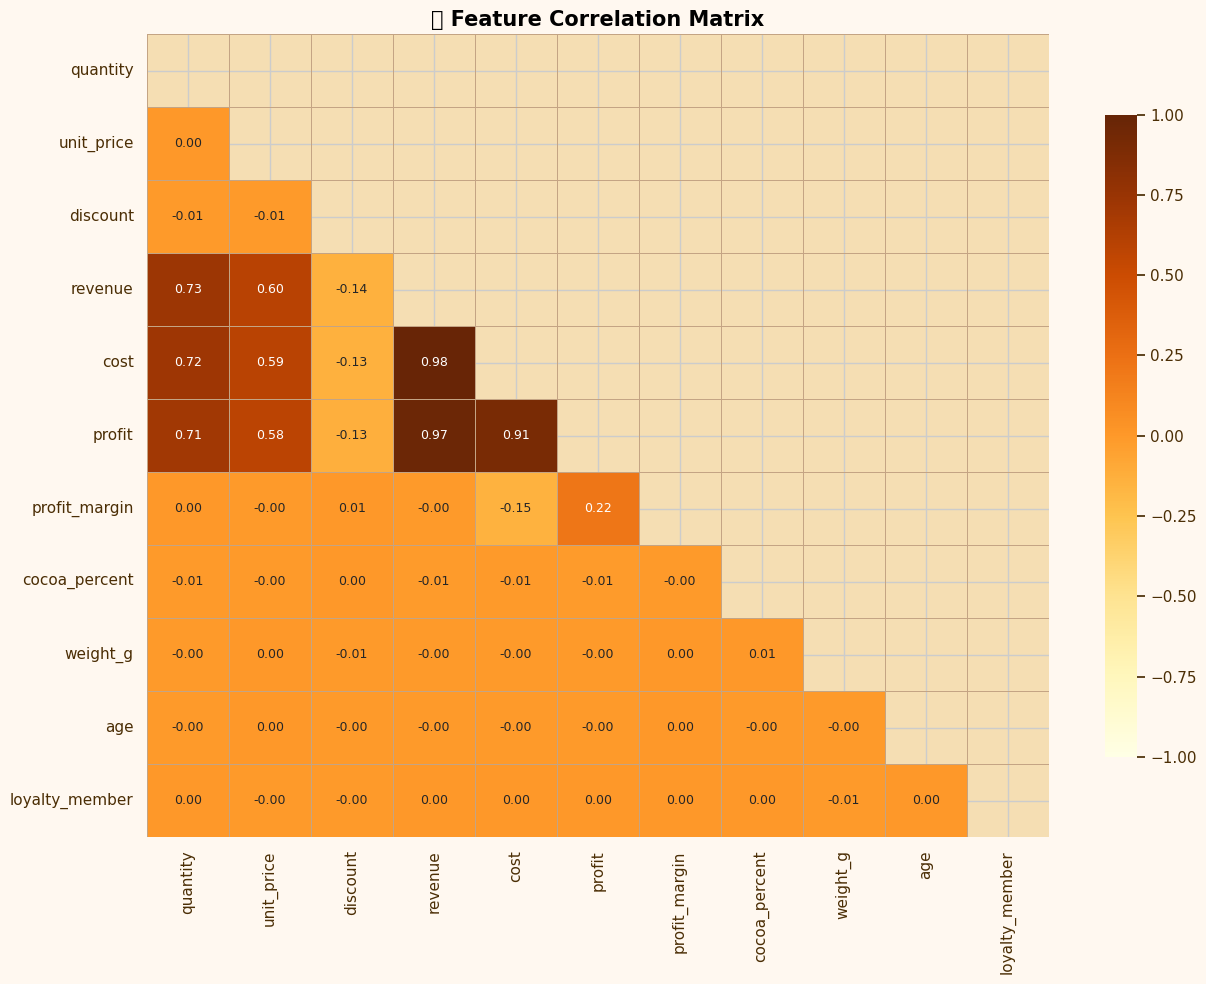

In [63]:
# ── Correlation heatmap ────────────────────────────────────────────────────────
num_cols = ['quantity','unit_price','discount','revenue','cost','profit',
            'profit_margin','cocoa_percent','weight_g','age','loyalty_member']
corr = df[num_cols].sample(50_000, random_state=42).corr()

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='YlOrBr', annot=True, fmt='.2f',
            linewidths=0.5, linecolor='#C4A484', ax=ax,
            annot_kws={'size':9}, vmin=-1, vmax=1,
            cbar_kws={'shrink':0.8})
ax.set_title('🔗 Feature Correlation Matrix', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

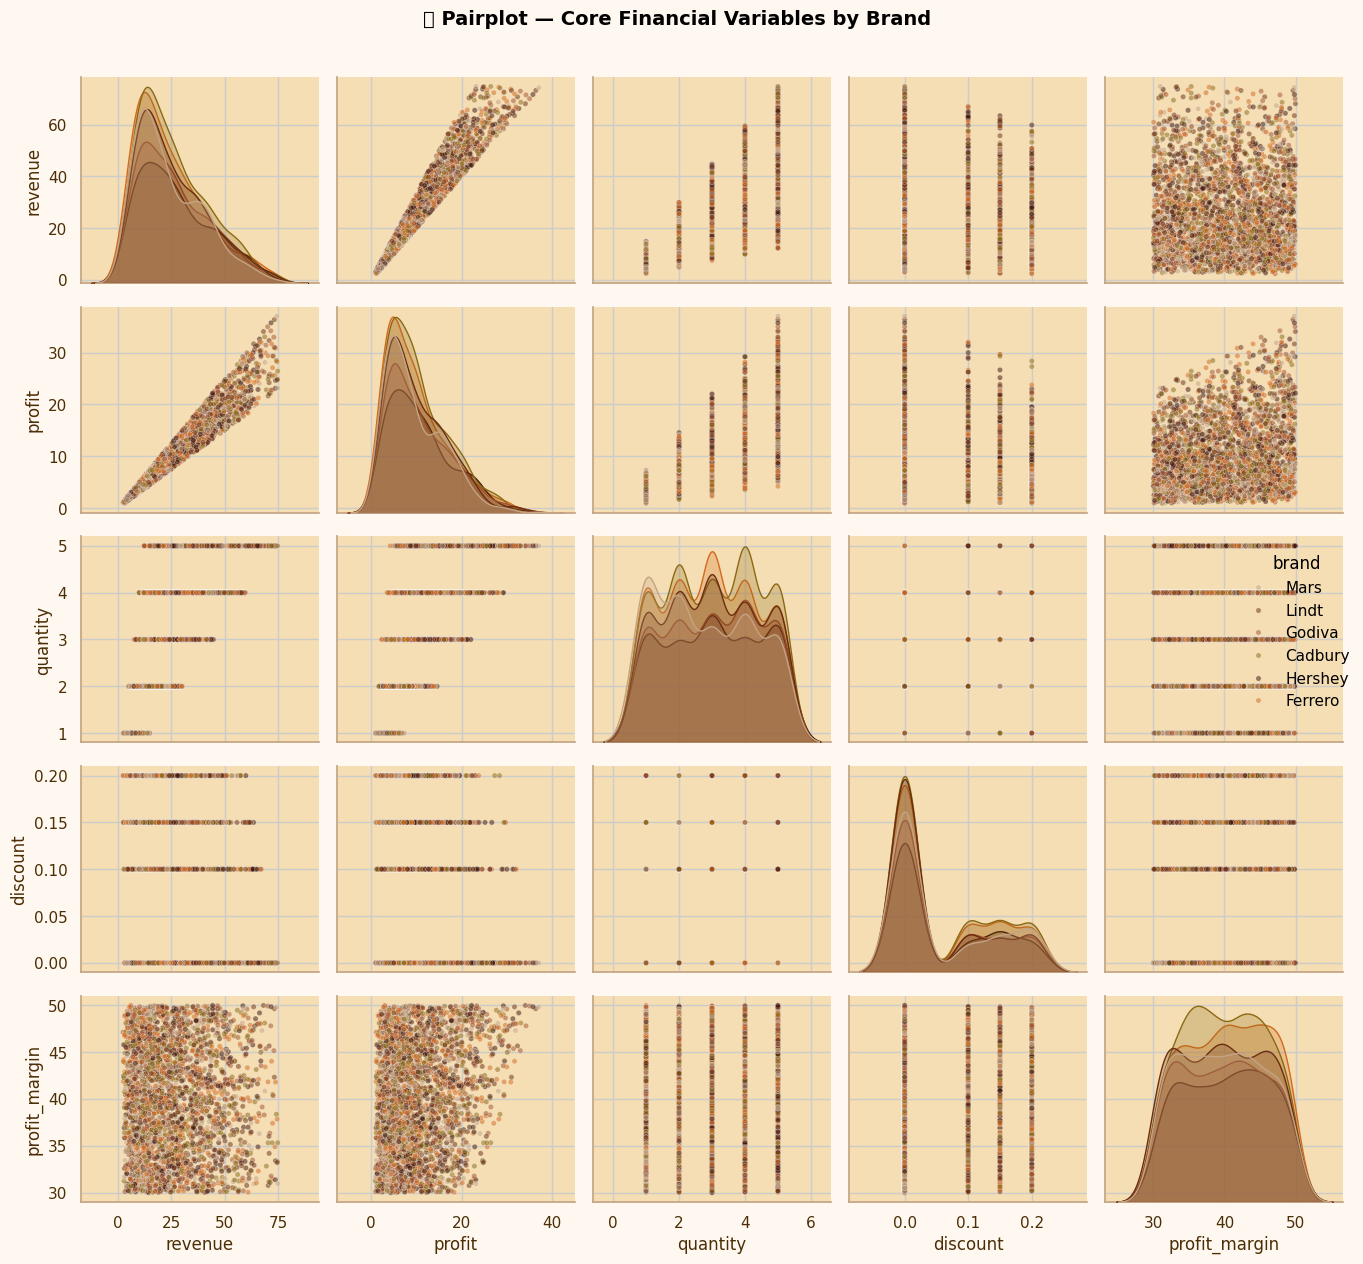

In [64]:
# ── Pairplot — core financials ─────────────────────────────────────────────────
sample = df[['revenue','profit','quantity','discount','profit_margin','brand']].sample(3000, random_state=42)
g = sns.pairplot(sample, hue='brand', palette=dict(zip(
        df['brand'].unique(), BRAND_PALETTE)),
        plot_kws={'alpha':0.5,'s':15}, diag_kind='kde',
        diag_kws={'fill':True})
g.fig.suptitle('🔍 Pairplot — Core Financial Variables by Brand',
               y=1.01, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

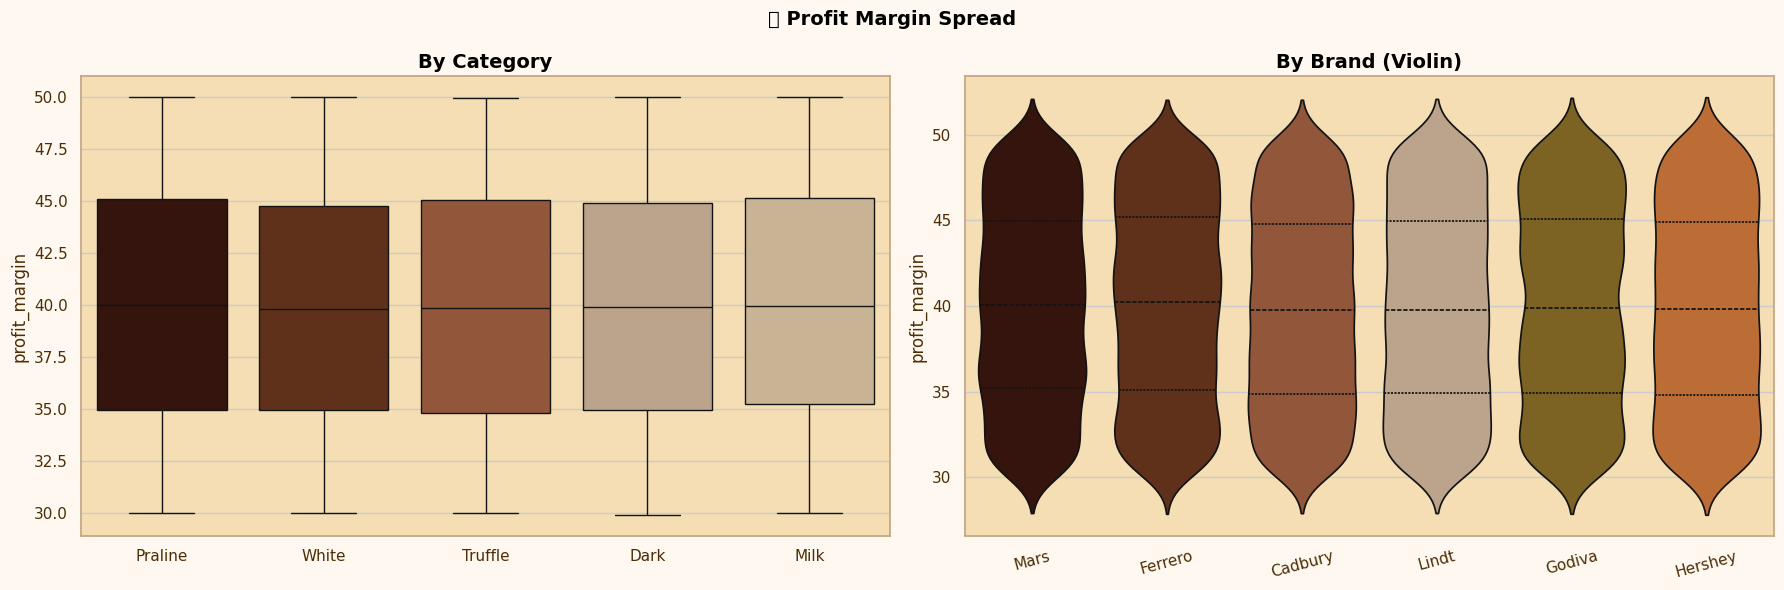

In [65]:
# ── Box plots — profit margin by category & brand ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('📦 Profit Margin Spread', fontsize=14, fontweight='bold')

sample2 = df.sample(30_000, random_state=1)
sns.boxplot(data=sample2, x='category', y='profit_margin',
            palette=CHOCO_PALETTE[:5], ax=axes[0])
axes[0].set_title('By Category', fontweight='bold')
axes[0].set_xlabel('')

sns.violinplot(data=sample2, x='brand', y='profit_margin',
               palette=BRAND_PALETTE, inner='quartile', ax=axes[1])
axes[1].set_title('By Brand (Violin)', fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

10. Profit Prediction (Regression)

In [66]:
# ── Feature prep ──────────────────────────────────────────────────────────────
reg_features = ['quantity','unit_price','discount','cost','cocoa_percent',
                'weight_g','age','loyalty_member','is_weekend','month','quarter',
                'day_of_week','has_discount']
cat_features = ['brand','category','country','store_type','gender']

ml_df = df[reg_features + cat_features + ['profit']].dropna().sample(200_000, random_state=42)

# Encode categoricals
le = LabelEncoder()
for c in cat_features:
    ml_df[c] = le.fit_transform(ml_df[c].astype(str))

X = ml_df.drop('profit', axis=1)
y = ml_df['profit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape}  |  Test: {X_test.shape}')

Train: (160000, 18)  |  Test: (40000, 18)


In [67]:
# ── Model training & evaluation ────────────────────────────────────────────────
models = {
    'Linear Regression'   : LinearRegression(),
    'Random Forest'       : RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingRegressor(n_estimators=200, max_depth=5,
                                                       learning_rate=0.1, random_state=42),
    'XGBoost'             : xgb.XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1,
                                              random_state=42, verbosity=0),
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = {
        'MAE' : mean_absolute_error(y_test, preds),
        'RMSE': np.sqrt(mean_squared_error(y_test, preds)),
        'R2'  : r2_score(y_test, preds),
        'preds': preds
    }
    print(f'{name:25s} | MAE={results[name]["MAE"]:.3f}  RMSE={results[name]["RMSE"]:.3f}  R²={results[name]["R2"]:.4f}')

Linear Regression         | MAE=1.927  RMSE=2.467  R²=0.8666
Random Forest             | MAE=0.555  RMSE=0.830  R²=0.9849
Gradient Boosting         | MAE=0.400  RMSE=0.512  R²=0.9942
XGBoost                   | MAE=0.216  RMSE=0.290  R²=0.9982


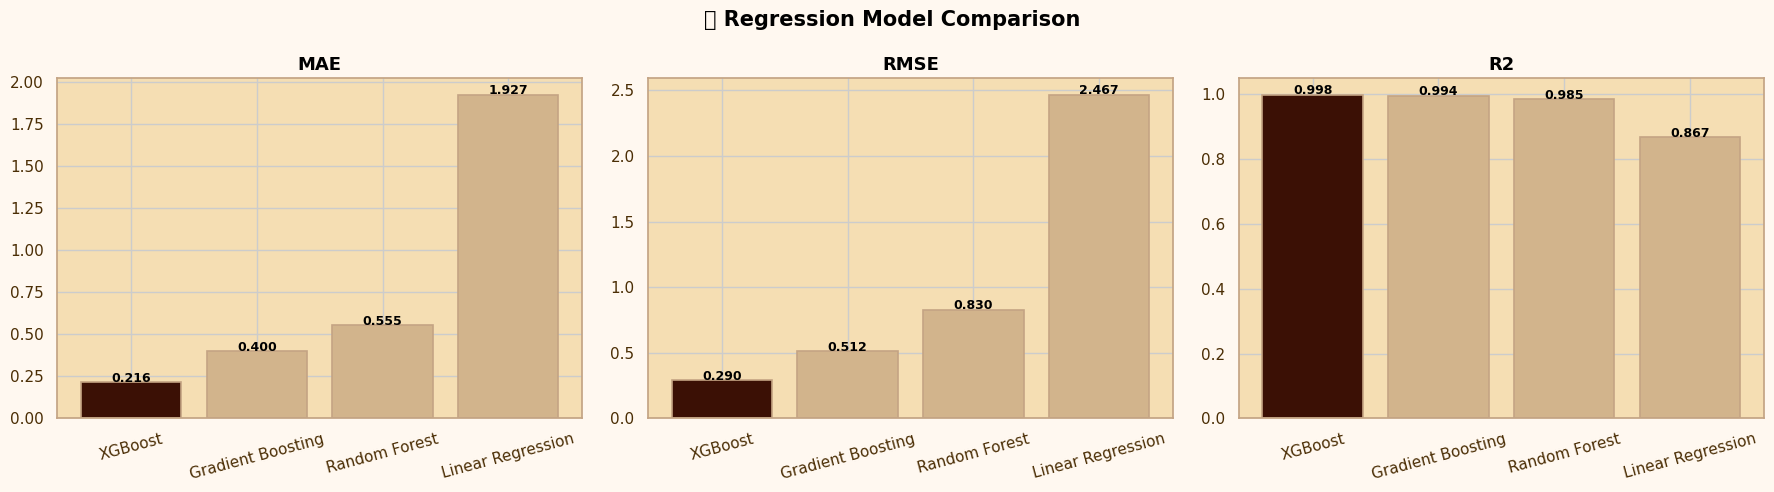

In [68]:
# ── Model comparison bar chart ────────────────────────────────────────────────
res_df = pd.DataFrame({k: {m: v for m, v in v.items() if m != 'preds'}
                       for k, v in results.items()}).T.reset_index()
res_df.columns = ['Model','MAE','RMSE','R2']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('🤖 Regression Model Comparison', fontsize=15, fontweight='bold')

for ax, metric, ascending in zip(axes, ['MAE','RMSE','R2'], [True,True,False]):
    data = res_df.sort_values(metric, ascending=ascending)
    colors = ['#3B1005' if i==0 else '#D2B48C' for i in range(len(data))]
    bars = ax.bar(data['Model'], data[metric], color=colors, edgecolor='#C4A484', linewidth=1.2)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.tick_params(axis='x', rotation=15)
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
                f'{bar.get_height():.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

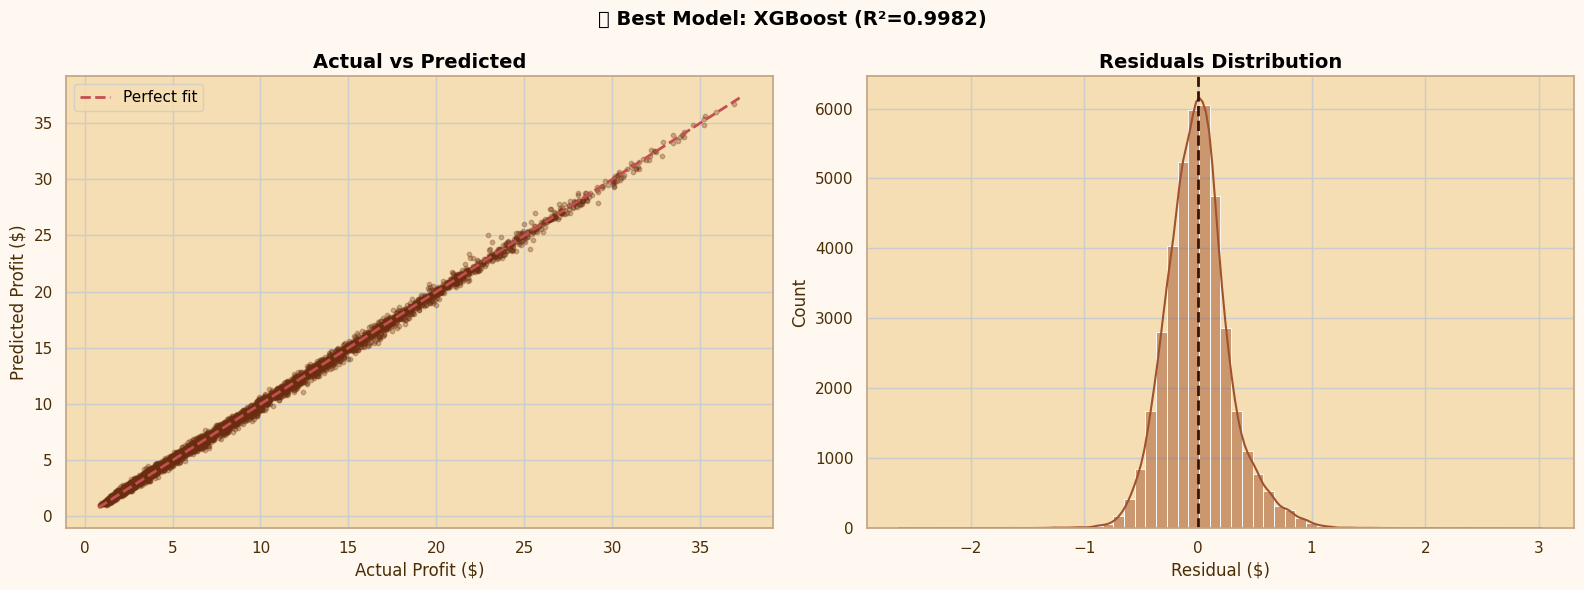

In [69]:
# ── Best model: Actual vs Predicted & Residuals ───────────────────────────────
best_name = max(results, key=lambda k: results[k]['R2'])
best_preds = results[best_name]['preds']
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'🏆 Best Model: {best_name} (R²={results[best_name]["R2"]:.4f})',
             fontsize=14, fontweight='bold')

# Actual vs predicted
idx = np.random.choice(len(y_test), 5000, replace=False)
axes[0].scatter(y_test.values[idx], best_preds[idx],
                alpha=0.3, color='#6B2D0F', s=10)
mn, mx = y_test.min(), y_test.max()
axes[0].plot([mn,mx],[mn,mx], 'r--', lw=2, label='Perfect fit')
axes[0].set_xlabel('Actual Profit ($)', color='#4B2E05')
axes[0].set_ylabel('Predicted Profit ($)', color='#4B2E05')
axes[0].set_title('Actual vs Predicted', fontweight='bold')
axes[0].legend()

# Residuals
sns.histplot(residuals, bins=60, color='#A0522D', kde=True, ax=axes[1])
axes[1].axvline(0, color='#3B1005', lw=2, ls='--')
axes[1].set_title('Residuals Distribution', fontweight='bold')
axes[1].set_xlabel('Residual ($)')

plt.tight_layout()
plt.show()

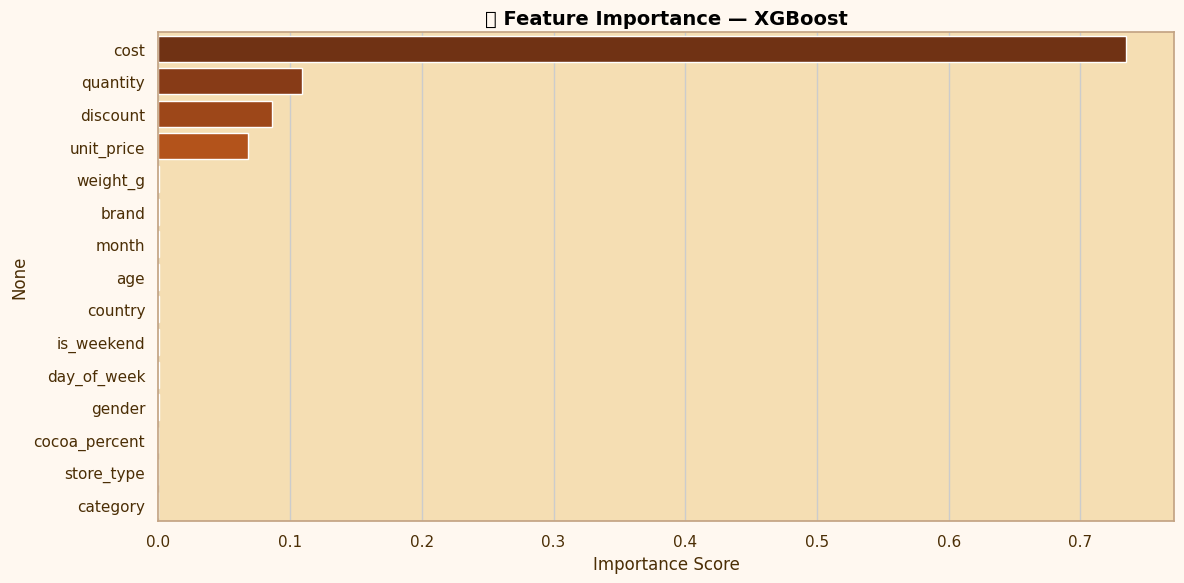

In [70]:
# ── Feature Importance ────────────────────────────────────────────────────────
best_model = [m for name, m in models.items() if name == best_name][0]

if hasattr(best_model, 'feature_importances_'):
    fi = pd.Series(best_model.feature_importances_, index=X.columns)\
           .sort_values(ascending=False).head(15)

    fig, ax = plt.subplots(figsize=(12, 6))
    colors = [CHOCO_PALETTE[min(i, len(CHOCO_PALETTE)-1)] for i in range(len(fi))]
    sns.barplot(x=fi.values, y=fi.index, palette='YlOrBr_r', ax=ax)
    ax.set_title(f'🔑 Feature Importance — {best_name}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Importance Score')
    plt.tight_layout()
    plt.show()